# Assignment 3 - IMDB Sentiment & Regularisation

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | |
| Used for | |
| Verified how | |
| Not used for | |

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Ollama qwen3.5:2b |
| Used for | installation of graph vis, learning rate schedule plot |
| Verified how | just needing the directory for download and troubleshooting plots when it wasnt working. For the final model, I planned what a class would look like to retain the learning rates information when training the model that reduces the learning rate over time |
| Not used for | creating models, writing code or evaluation |

## Inputs

In [ ]:
# Imports
import matplotlib.pyplot as plt
from keras.datasets import imdb
from keras import layers, Sequential
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from keras.utils import plot_model, pad_sequences
from keras.models import load_model

# Globals
MAX_FEATURES = 10000
MAX_LEN = 500
DROPOUT_RATE = 0.1
EPOCHS = 50
BATCH_SIZE = 64 # Smaller batch size

USE_L2 = False
USE_DROPOUT = True
USE_EARLY_STOP = True

MODEL_FILE = "imdb_sentiment_best.keras"

### Methods

In [ ]:
# Logging for lr plot
class LRLOGGER(Callback):
    # Initialise an array for learning rates
    def on_train_begin(self):
        self.lrs = []
    # At the end of each epoch, save the learning rate to the array
    def on_epoch_end(self):
        lr = self.model.optimizer.learning_rate # Initialise the learning rate optimiser
        # Try add the learning rate, using numpy is rounding error
        try:
            self.lrs.append(float(lr))
        except TypeError:
            self.lrs.append(float(lr.numpy()))

# Padding sequences
def pad_x(x):
    return pad_sequences(x, MAX_LEN)

# Validation split
def validation_split(x_train, y_train, size=MAX_FEATURES):
    """Returns: x_val, y_val, x_train, y_train"""
    return x_train[:size], y_train[:size], x_train[size:], y_train[size:]

def build_model(is_base=True):
    """is_base : Default true (no dropout)
        returns: Compiled model"""
    model = Sequential([
        layers.Embedding(MAX_FEATURES, 32, name="embedding_layer"),
        layers.GlobalAveragePooling1D(name="average_pooling"),
        layers.Dense(16, activation='relu', name='relu_1')      # Changed layer from 32 to 16 improving val accuracy
    ])
    if not is_base:
        model.add(layers.Dropout(DROPOUT_RATE, name='dropout_2'))
    model.add(layers.Dense(1, activation='sigmoid', name='sigmoid_output'))
    return compile_model(model)
    
def compile_model(model):
    """Compiles the model and returns it"""
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model
    
        
def initialise_callbacks(is_lr):
    """is_lr: for the learning rate optimisation
        returns: early stopping callback and None
        OR if is_lr=True adds the learning rate callback and returns it"""
    callbacks = [early_stopping()]
    lr_logger = None
    if is_lr:
        lr_logger = LRLOGGER()
        callbacks.append(reduce_lr())
        callbacks.append(lr_logger)
    return callbacks, lr_logger
        

def early_stopping():
    """Initialises early stopping"""
    return EarlyStopping(
        monitor='val_loss', # Reduces stopping at a lower accuracy when with no reduced learning rate
        patience=5, # 10% of the 50 epochs
        restore_best_weights=True
    )
    
def reduce_lr():
    return ReduceLROnPlateau(
        monitor='val_loss', # Used plataeu around higher accuracies than plateau earlier on val_acc
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )

def fit_model(model, x_train, y_train, x_val, y_val, is_base=True, is_lr=False):
    # Fit the baseline model
    if is_base:
        history = model.fit(
            x_train,
            y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_data=(x_val, y_val),
            verbose=1       
        )
    else:
        # Fit model with amount of callbacks required (earlystopping /and learningrate)
        callbacks, lr_logger = initialise_callbacks(is_lr)
        history = model.fit(
            x_train,
            y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_data=(x_val, y_val),
            callbacks=callbacks,
            verbose=1       
        )
    return history, lr_logger
    
# Get best validation accuracy
def best_validation(history): # Highest accuracy recorded not last recorded
    return max(history.history["val_accuracy"])

def get_best_model():
    """Based on the models and value accuracies returns the highest scoring model"""
    accuracies = [baseline_val_acc, improved_val_acc, lr_improved_val_acc]
    print(f"Baseline acc: {accuracies[0]} Improved acc: {accuracies[1]}  lr acc: {accuracies[2]}")
    return [baseline, improved, lr][accuracies.index(max(accuracies))]
    
def evaluate_model(model):
    """Evaluates the model based on the test accuracy"""
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Final test accuracy of best model {test_acc}")
    
def plot_lr(lr_logger):
    """Plots the learning rate recorded in training"""
    if lr_logger is None or not lr_logger.lrs:
        print("No learning rate available")
        return
    plt.plot(lr_logger.lrs)
    plt.xlabel("Epoch")
    plt.xticks(range(1, len(lr_logger.lrs) + 1)) # Because the lr is recorded at each epoch 
    plt.ylabel("Learning Rate")
    plt.title("LR Schedule")
    plt.show()
    
    

## Load IMDB, pad sequences, create a train / validation split

In [4]:
# Load data
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

# Pad sequences
x_train = pad_x(x_train)
x_test = pad_x(x_test)

# Validation split
x_val, y_val, x_train, y_train = validation_split(x_train, y_train)

print(f"Train X: {x_train.shape}, Train y: {y_train.shape}")
print(f"Val X: {x_val.shape}, Val y: {y_val.shape}")
print(f"Test X: {x_test.shape}, Test y: {y_test.shape}")

Train X: (15000, 500), Train y: (15000,)
Val X: (10000, 500), Val y: (10000,)
Test X: (25000, 500), Test y: (25000,)


## Train a baseline sentiment model and record best validation accuracy

In [ ]:
# training pipeline
baseline = build_model()
baseline_hist, _ = fit_model(baseline, x_train, y_train, x_val, y_val)
baseline_val_acc = best_validation(baseline_hist)
print(f"Baseline best val accuracy {baseline_val_acc}")

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5730 - loss: 0.6811 - val_accuracy: 0.5610 - val_loss: 0.6656
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7331 - loss: 0.5670 - val_accuracy: 0.8202 - val_loss: 0.4769
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8309 - loss: 0.4126 - val_accuracy: 0.8422 - val_loss: 0.3812
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8607 - loss: 0.3415 - val_accuracy: 0.8668 - val_loss: 0.3367
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8758 - loss: 0.3038 - val_accuracy: 0.8762 - val_loss: 0.3120
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8836 - loss: 0.2854 - val_accuracy: 0.8246 - val_loss: 0.3730
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8923 - loss: 0.2623 - val_accuracy: 0.8710 - val_loss: 0.3055
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9055 - loss: 0.2368 - val_accu

## Produce a diagram of the model architecture

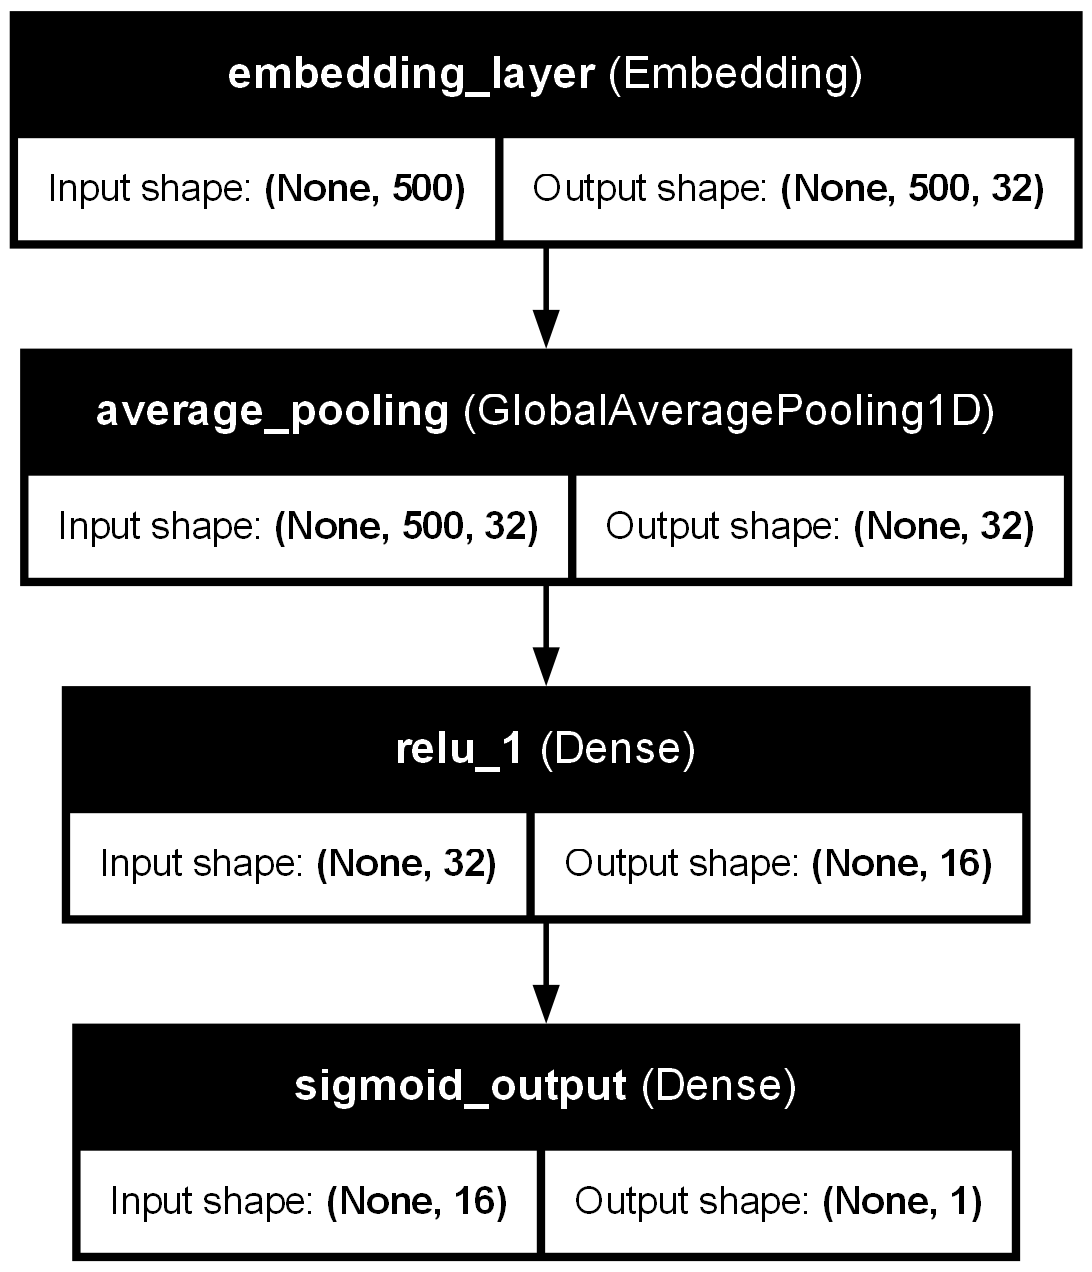

In [6]:
#print(baseline.summary())

plot_model(
    baseline,
    to_file="imdb_model.png",
    show_shapes=True,
    show_layer_names=True
)

## Apply dropout and early stopping - report best val accuracy and name the techniques

In [ ]:
# training pipeline improved
improved = build_model(False)
improved_hist, _ = fit_model(improved, x_train, y_train, x_val, y_val, False)
improved_val_acc = best_validation(improved_hist)
print(f"Improved best val accuracy {improved_val_acc}")

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5425 - loss: 0.6870 - val_accuracy: 0.6783 - val_loss: 0.6656
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6938 - loss: 0.6116 - val_accuracy: 0.8048 - val_loss: 0.5316
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7900 - loss: 0.4726 - val_accuracy: 0.8354 - val_loss: 0.4112
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8468 - loss: 0.3755 - val_accuracy: 0.8485 - val_loss: 0.3607
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8609 - loss: 0.3336 - val_accuracy: 0.8672 - val_loss: 0.3302
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8751 - loss: 0.3056 - val_accuracy: 0.8783 - val_loss: 0.3070
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8979 - loss: 0.2633 - val_accuracy: 0.8683 - val_loss: 0.3107
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9017 - loss: 0.2473 - val_accu

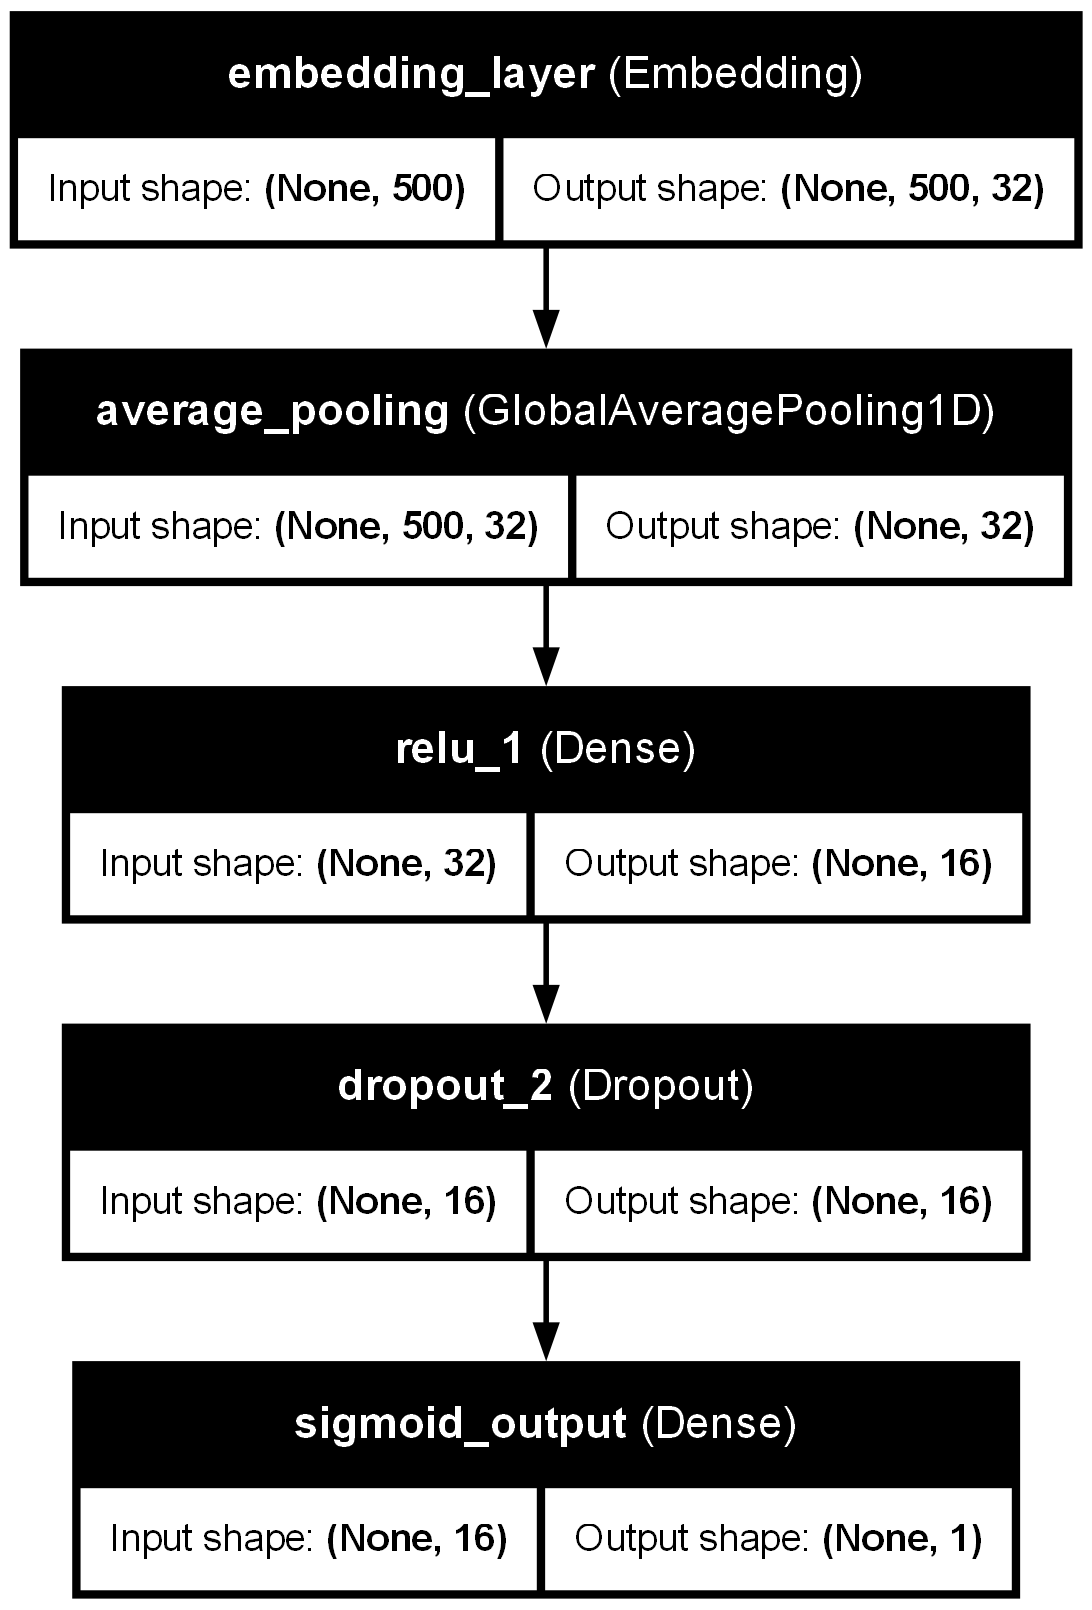

In [8]:
plot_model(
    improved,
    to_file="imdb_improved_model.png",
    show_shapes=True,
    show_layer_names=True
)

## Learning-rate schedule experiment

In [ ]:
# training pipeline improved with learning rate adjustments over epochs
lr = build_model(False)
lr_hist, lr_logger = fit_model(lr, x_train, y_train, x_val, y_val, False, True)
lr_improved_val_acc = best_validation(lr_hist)
print(f"Learning Rate Improved best val accuracy {lr_improved_val_acc}")

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5497 - loss: 0.6859 - val_accuracy: 0.7159 - val_loss: 0.6593 - learning_rate: 0.0010
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6872 - loss: 0.6021 - val_accuracy: 0.7968 - val_loss: 0.5117 - learning_rate: 0.0010
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8015 - loss: 0.4577 - val_accuracy: 0.8128 - val_loss: 0.4171 - learning_rate: 0.0010
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8411 - loss: 0.3754 - val_accuracy: 0.8650 - val_loss: 0.3490 - learning_rate: 0.0010
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8696 - loss: 0.3195 - val_accuracy: 0.8539 - val_loss: 0.3373 - learning_rate: 0.0010
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8718 - loss: 0.3006 - val_accuracy: 0.8546 - val_loss: 0.3303 - learning_rate: 0.0010
Epoch 7/50
229/235 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8907 - loss: 0.26

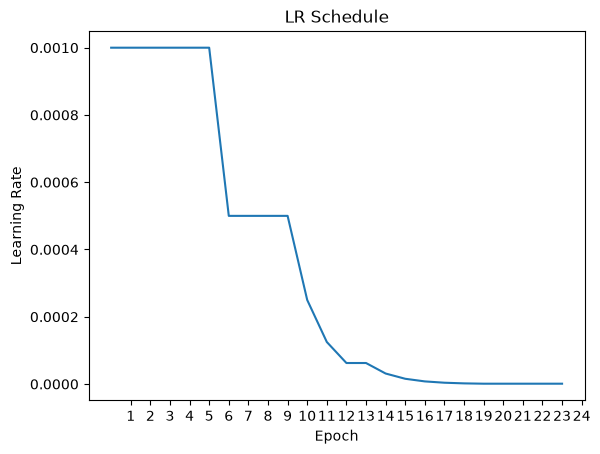

In [13]:
plot_lr(lr_logger)

LR experiment notes:

- Schedule used: ReduceLROnPlateau
- Observed effect on val curves / final accuracy:
  From what I noted on the training data is that the val accuracy would plateau early and slowly make minor improvements in accuracy before reducing again after 30-50 epochs,
  so by focusing on finding a very low validation loss area, which was associated with the record accuracy models, the learning rate quickly drops around an area of highest accuracy compared to the baseline.
- Would you keep this schedule for a real project?
  I would probably change some of the parameters to slow the reduction of learning rate in some more complex models however for this task it worked well based off training.

## Save the model

In [17]:
best_model = get_best_model()

best_model.save(MODEL_FILE)
print(f"Saved model file {MODEL_FILE}")

# Reload and evaluate test
model = load_model(MODEL_FILE)
evaluate_model(best_model)

Baseline acc: 0.8902999758720398 Improved acc: 0.8909000158309937  lr acc: 0.8913999795913696
Saved model file imdb_sentiment_best.keras
Final test accuracy of best model 0.8841599822044373


## Summary
Baseline acc:                                                           0.8902999758720398 
Improved (dropout and early stopping) acc:                              0.8909000158309937  
LR (dropout, early stopping and reducing learning rate) acc:            0.8913999795913696
Test Accuracy:                                                          0.8841599822044373

The baseline model performed pretty well without any regularisation, when repeating training occasionally the baseline model would outperform one of the other regularised models.
I reduced the size of the embedding layer from 32 to 16 as it marginally improves the accuracy, so I prioritised minimising the layer sizes where possible. 
With the learning rate model, I trialled both including and excluding EarlyStopping and Dropout. Finding that when excluding dropout the accuracy can be a lot more inconsistent. I created a class to store the learning rates during training as I was struggling to retrieve this information from the model after training. To fully implement early stopping correctly, I increased the epochs to 50 with a patience of 5. Although there was little improvement in the base model after 30 epochs, in the regularised models, improvement was sometimes regained at higher epochs, or plataued for a few epochs consecutively before improving again, so I did not want to prematurely end training due to a low patience threshold. The full model only required 19 epochs before it outperformed the other models validation accuracy. I did not use L2 regularisation, so if given the opportunity I would trial the impact of L2 on the existing models to see if it improved performance. However, I am satisfied with a 0.88 test accuracy compared to the 0.89 validation accuracy given by the learning rate model with drop out and early stopping.